In [2]:
pip install torch torchvision matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable
  Using cached torch-2.12.1-cp312-cp312-win_amd64.whl.metadata (31 kB)
  Using cached torchvision-0.27.1-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached matplotlib-3.11.0-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached torch-2.12.1-cp312-cp312-win_amd64.whl (123.0 MB)
Using cached torchvision-0.27.1-cp312-cp312-win_amd64.whl (4.1 MB)
Using cached matplotlib-3.11.0-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63

ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\This PC\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\torch\\include\\ATen\\native\\transformers\\cuda\\mem_eff_attention\\iterators\\predicated_tile_access_iterator_residual_last.h'


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\This PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
pip install torch torchvision matplotlib numpy

  Using cached torch-2.12.1-cp312-cp312-win_amd64.whl.metadata (31 kB)
  Using cached torchvision-0.27.1-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached matplotlib-3.11.0-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached numpy-2.5.0-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached filelock-3.29.4-py3-none-any.whl.metadata (2.0 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.6.0-py3-none-any.whl.metadata (10 kB)
  Using cached pillow-12.2.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1

In [3]:
# Cell 1 — Imports & Device Setup
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print("Classes:", classes)

Using device: cpu
Classes: ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


In [4]:
# Cell 2 — Load CIFAR-10 Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download and load training data
trainset = torchvision.datasets.CIFAR10(
    root='../data', train=True, download=True, transform=transform
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=32, shuffle=True
)

# Download and load test data
testset = torchvision.datasets.CIFAR10(
    root='../data', train=False, download=True, transform=transform
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=32, shuffle=False
)

print("Training samples:", len(trainset))
print("Testing samples: ", len(testset))

100.0%


Training samples: 50000
Testing samples:  10000


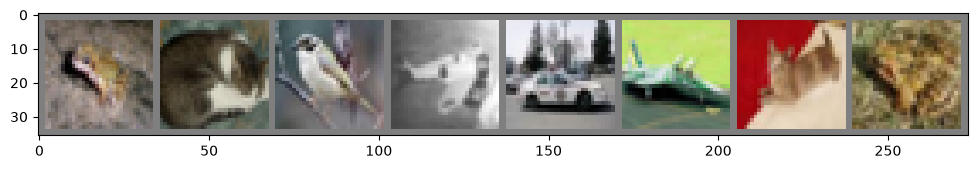

Labels: frog | cat | bird | plane | car | plane | cat | frog


In [5]:
# Cell 3 — Visualize Sample Images
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images
plt.figure(figsize=(12, 3))
imshow(torchvision.utils.make_grid(images[:8]))
print("Labels:", ' | '.join(classes[labels[j]] for j in range(8)))

In [6]:
# Cell 4 — CNN Architecture
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)   # 3 color channels in, 32 filters out
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)  # 32 in, 64 filters out
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1) # 64 in, 128 filters out
        
        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 64)
        self.fc3 = nn.Linear(64, 10)  # 10 classes
        
        # Regularization
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 32x32 -> 16x16
        x = self.pool(self.relu(self.conv2(x)))  # 16x16 -> 8x8
        x = self.pool(self.relu(self.conv3(x)))  # 8x8   -> 4x4
        
        x = x.view(-1, 128 * 4 * 4)  # flatten
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

# Initialize model
model = CNN().to(device)
print(model)
print("\nTotal parameters:", sum(p.numel() for p in model.parameters()))

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (relu): ReLU()
)

Total parameters: 1175818


In [7]:
# Cell 5 — Training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
epochs = 10

for epoch in range(epochs):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs} — Loss: {epoch_loss:.4f}")

print("\nTraining Complete! ✅")

Epoch 1/10 — Loss: 1.6275
Epoch 2/10 — Loss: 1.2048
Epoch 3/10 — Loss: 1.0274
Epoch 4/10 — Loss: 0.9095
Epoch 5/10 — Loss: 0.8299
Epoch 6/10 — Loss: 0.7623
Epoch 7/10 — Loss: 0.7104
Epoch 8/10 — Loss: 0.6574
Epoch 9/10 — Loss: 0.6202
Epoch 10/10 — Loss: 0.5762

Training Complete! ✅


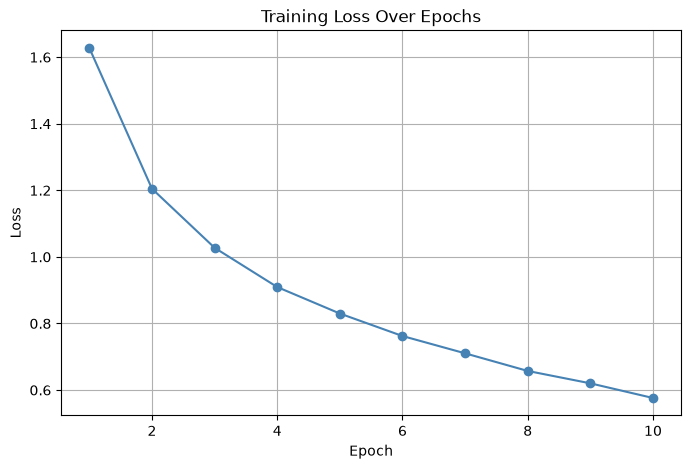

In [8]:
# Cell 6 — Plot Training Loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), train_losses, marker='o', color='steelblue')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [9]:
# Cell 7 — Test Accuracy
model.eval()  # switch to evaluation mode
correct = 0
total = 0

with torch.no_grad():  # no need to calculate gradients during testing
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 75.65%


In [10]:
# Cell 8 — Per-Class Accuracy
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval()
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

print("Per-Class Accuracy:")
for i in range(10):
    print(f"  {classes[i]:8s}: {100 * class_correct[i] / class_total[i]:.2f}%")

Per-Class Accuracy:
  plane   : 84.70%
  car     : 84.80%
  bird    : 64.30%
  cat     : 58.50%
  deer    : 75.40%
  dog     : 62.80%
  frog    : 80.60%
  horse   : 73.10%
  ship    : 83.60%
  truck   : 88.70%


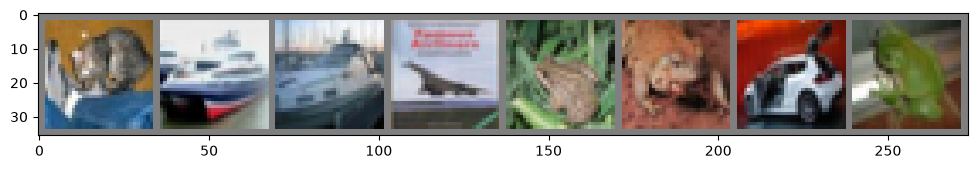

Actual:     cat | ship | ship | plane | frog | frog | car | frog
Predicted:  cat | ship | ship | plane | frog | frog | truck | bird


In [11]:
# Cell 9 — Visualize Predictions
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

plt.figure(figsize=(12, 4))
imshow(torchvision.utils.make_grid(images[:8].cpu()))
print("Actual:    ", ' | '.join(classes[labels[j]] for j in range(8)))
print("Predicted: ", ' | '.join(classes[predicted[j]] for j in range(8)))

In [12]:
# Cell 10 — Save Model
torch.save(model.state_dict(), '../src/cnn_cifar10_model.pth')
print("Model saved! ✅")

Model saved! ✅
